In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
print("All libraries imported successfully.")

All libraries imported successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MEGHLA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [8]:
file='C:/Users/MEGHLA/Downloads/unzip/spam.csv'
df =pd.read_csv('C:/Users/MEGHLA/Downloads/unzip/spam.csv', encoding='latin-1')
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df['label'] = df['label'].map({'spam': 1, 'ham': 0, 'Spam': 1, 'Ham': 0})
df = df.dropna(subset=['label', 'message'])
print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:")
print(f"   Spam: {df[df['label']==1].shape[0]} messages")
print(f"   Ham:  {df[df['label']==0].shape[0]} messages")
print(f"   Spam percentage: {(df[df['label']==1].shape[0]/len(df)*100):.2f}%")

Dataset loaded successfully!
Dataset shape: (5572, 5)
Class distribution:
   Spam: 747 messages
   Ham:  4825 messages
   Spam percentage: 13.41%


In [9]:
#copying the dataset for preprocessing
df_processed=df.copy()
#cleaning the messages(lowercase, removing special characters and extra spaces if any)
df_processed['clean_message'] = df_processed['message'].str.lower().str.strip()
df_processed['clean_message'] = df_processed['message'].str.replace('[^\w\s]', '', regex=True)
df_processed['clean_message'] = df_processed['clean_message'].str.replace('\s+', ' ', regex=True)
print(f"Sample original: {df_processed['message'].iloc[0][:100]}...")
print(f"Sample cleaned: {df_processed['clean_message'].iloc[0][:100]}...")

Sample original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a...
Sample cleaned: Go until jurong point crazy Available only in bugis n great world la e buffet Cine there got amore w...


<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MEGHLA\AppData\Local\Temp\ipykernel_18400\3712471958.py:5: SyntaxWarning: invalid escape sequence '\w'
  df_processed['clean_message'] = df_processed['message'].str.replace('[^\w\s]', '', regex=True)
C:\Users\MEGHLA\AppData\Local\Temp\ipykernel_18400\3712471958.py:6: SyntaxWarning: invalid escape sequence '\s'
  df_processed['clean_message'] = df_processed['clean_message'].str.replace('\s+', ' ', regex=True)


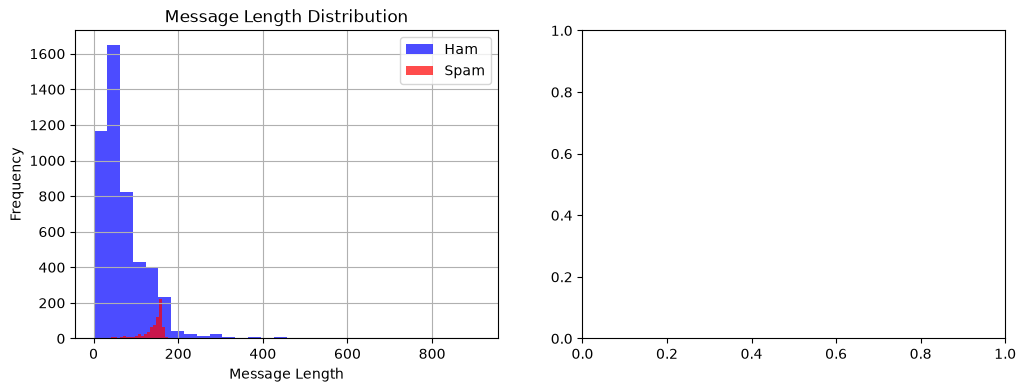

In [ ]:
df_processed['message_length'] = df_processed['message'].str.len()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#histogram of message lengths for ham and spam
df_processed[df_processed['label']==0]['message_length'].hist(ax=axes[0], bins=30, alpha=0.7, color='blue', label='Ham')
df_processed[df_processed['label']==1]['message_length'].hist(ax=axes[0], bins=30, alpha=0.7, color='red', label='Spam')
axes[0].set_xlabel('Message Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Message Length Distribution')
axes[0].legend()

In [13]:
print(f"   Average Ham length:  {df_processed[df_processed['label']==0]['message_length'].mean():.2f} chars")
print(f"   Average Spam length: {df_processed[df_processed['label']==1]['message_length'].mean():.2f} chars")

   Average Ham length:  71.02 chars
   Average Spam length: 138.87 chars


In [14]:
print("\nExtracting TF-IDF features...")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True)
X = tfidf_vectorizer.fit_transform(df_processed['clean_message'])
y = df_processed['label'].values
print(f"TF-IDF features extracted!")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
# Displaying top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nTop 10 features: {', '.join(feature_names[:10])}")


Extracting TF-IDF features...
TF-IDF features extracted!
Feature matrix shape: (5572, 5000)
Number of features: 5000

Top 10 features: 01223585334, 01223585334 cum, 020603, 020603 2nd, 02073162414, 02073162414 costs, 020903, 020903 2nd, 021, 050703


In [16]:
#splitting the dataser
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f"   Training spam %:   {(y_train.sum()/len(y_train)*100):.2f}%")
print(f"   Testing spam %:    {(y_test.sum()/len(y_test)*100):.2f}%")

   Training spam %:   13.42%
   Testing spam %:    13.36%


In [18]:
#initializing and training the model
nb_model=MultinomialNB(alpha=1.0, fit_prior=True)
nb_model.fit(X_train, y_train)
#predicting test
y_pred=nb_model.predict(X_test)
y_pred_proba=nb_model.predict_proba(X_test)[:,1]
#model evaluation
accuracy=accuracy_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)
print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Model Performance:
Accuracy: 0.9686
Precision: 0.9914
Recall: 0.7718
F1-Score: 0.8679
